### Visualize the preprocessed data

This is what the model will see. We also want to gain distribution insights for normalization.


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/preproc_coins.csv')
df.head()

,time_idx,symbol,open_log,high_log,low_log,close_log,volume_log,btc_close_log,eth_close_log,eth_btc_ratio,hour_sin,hour_cos,norm_day_sin,norm_day_cos,weekday_sin,weekday_cos,month_sin,month_cos,year,next_close_log
0,0,ADA/USD,0.042488,-0.035411,0.017805,-0.017555,14.620035,-0.005870,-0.004027,0.063330,0.965926,2.588190e-01,-0.406737,-0.913545,0.781831,0.62349,0.866025,-0.5,0.8,-0.020670
1,1,ADA/USD,-0.016604,-0.051752,-0.047637,-0.020670,14.582821,0.005249,0.004362,0.063273,1.000000,6.123234e-17,-0.406737,-0.913545,0.781831,0.62349,0.866025,-0.5,0.8,0.001324
2,2,ADA/USD,-0.021549,-0.003644,0.027403,0.001324,14.010766,0.014037,0.012739,0.063191,0.965926,-2.588190e-01,-0.406737,-0.913545,0.781831,0.62349,0.866025,-0.5,0.8,-0.002611
3,3,ADA/USD,-0.001014,-0.011549,-0.010253,-0.002611,13.705804,-0.000842,0.004153,0.063508,0.866025,-5.000000e-01,-0.406737,-0.913545,0.781831,0.62349,0.866025,-0.5,0.8,-0.003713
4,4,ADA/USD,-0.000195,-0.000693,0.002810,-0.003713,13.441326,0.001574,0.003151,0.063608,0.707107,-7.071068e-01,-0.406737,-0.913545,0.781831,0.62349,0.866025,-0.5,0.8,0.003986


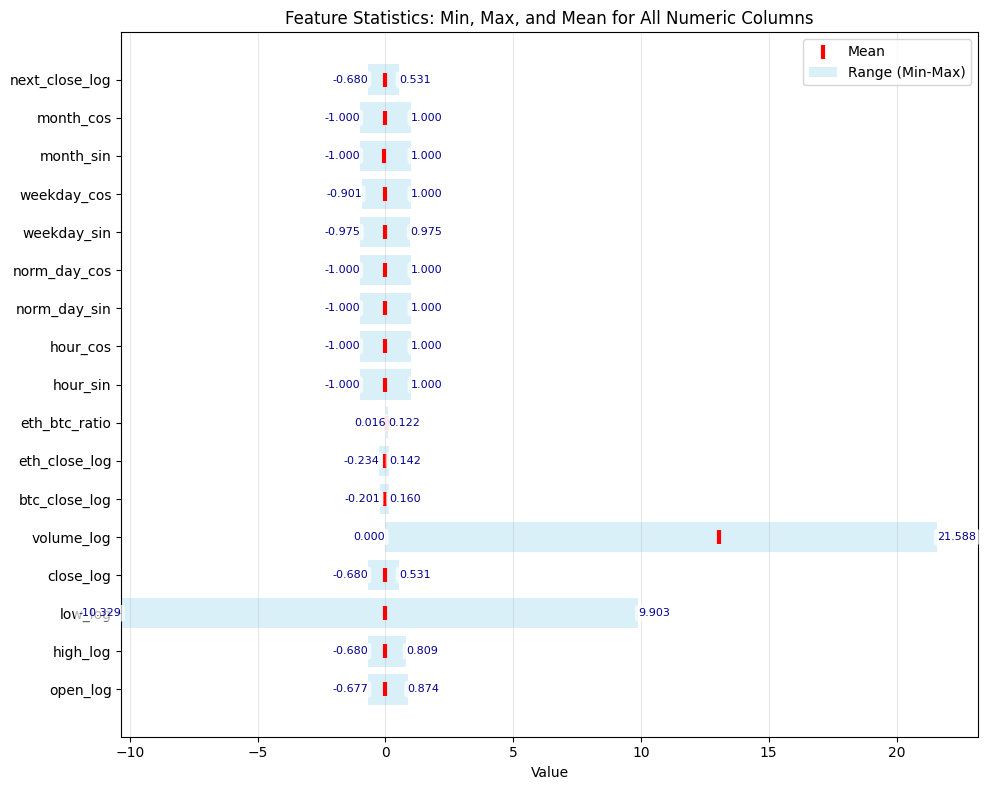

In [3]:
# Summary statistics visualization for all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Exclude time_idx and year
numeric_cols = [col for col in numeric_cols if col not in ['time_idx', 'year']]

# Calculate min, max, mean for each numeric column
stats = pd.DataFrame(
  {
    'min': df[numeric_cols].min(),
    'max': df[numeric_cols].max(),
    'mean': df[numeric_cols].mean(),
  }
)

# Create horizontal bar chart showing range with mean marker
fig, ax = plt.subplots(figsize=(10, 8))

y_pos = np.arange(len(stats))
ranges = stats['max'] - stats['min']

# Plot ranges as horizontal bars
ax.barh(
  y_pos, ranges, left=stats['min'], alpha=0.3, color='skyblue', label='Range (Min-Max)'
)

# Plot mean as red markers
ax.scatter(
  stats['mean'],
  y_pos,
  color='red',
  s=100,
  zorder=3,
  label='Mean',
  marker='|',
  linewidths=3,
)

# Add min/max annotations
for i, (idx, row) in enumerate(stats.iterrows()):
  # Min label (left side)
  ax.text(
    row['min'],
    i,
    f'{row["min"]:.3f}',
    ha='right',
    va='center',
    fontsize=8,
    color='darkblue',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.7),
  )
  # Max label (right side)
  ax.text(
    row['max'],
    i,
    f'{row["max"]:.3f}',
    ha='left',
    va='center',
    fontsize=8,
    color='darkblue',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.7),
  )

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(stats.index)
ax.set_xlabel('Value')
ax.set_title('Feature Statistics: Min, Max, and Mean for All Numeric Columns')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Check distribution


In [4]:
def histo(df, col_name, ax=None, std_band=5, bins=100):
  mean = df[col_name].mean()
  std = df[col_name].std()
  lower = mean - std_band * std
  upper = mean + std_band * std
  col_min = df[col_name].min()
  col_max = df[col_name].max()
  q1 = df[col_name].quantile(0.05)
  q3 = df[col_name].quantile(0.95)
  mid = df[col_name].median()

  # Use provided axis or create new figure
  if ax is None:
    fig, ax = plt.subplots()

  sns.histplot(data=df, x=col_name, bins=bins, kde=False, ax=ax)
  ax.set_xlim(lower, upper)
  ax.axvline(
    col_min, color='red', linestyle='--', linewidth=1.5, label=f'Min: {col_min:.4f}'
  )
  ax.axvline(
    col_max, color='red', linestyle='--', linewidth=1.5, label=f'Max: {col_max:.4f}'
  )
  ax.axvline(q1, color='green', linestyle='--', linewidth=1.5, label=f'Q5: {q1:.4f}')
  ax.axvline(q3, color='green', linestyle='--', linewidth=1.5, label=f'Q95: {q3:.4f}')
  ax.axvline(
    mean, color='orange', linestyle='--', linewidth=1.5, label=f'mean: {mean:.4f}'
  )
  ax.axvline(mid, color='black', linestyle='--', linewidth=1.5, label=f'mid: {mid:.4f}')
  ax.legend(fontsize=7)
  ax.set_title(col_name, fontsize=10)

  # Only show if no axis was provided
  if ax is None:
    plt.show()

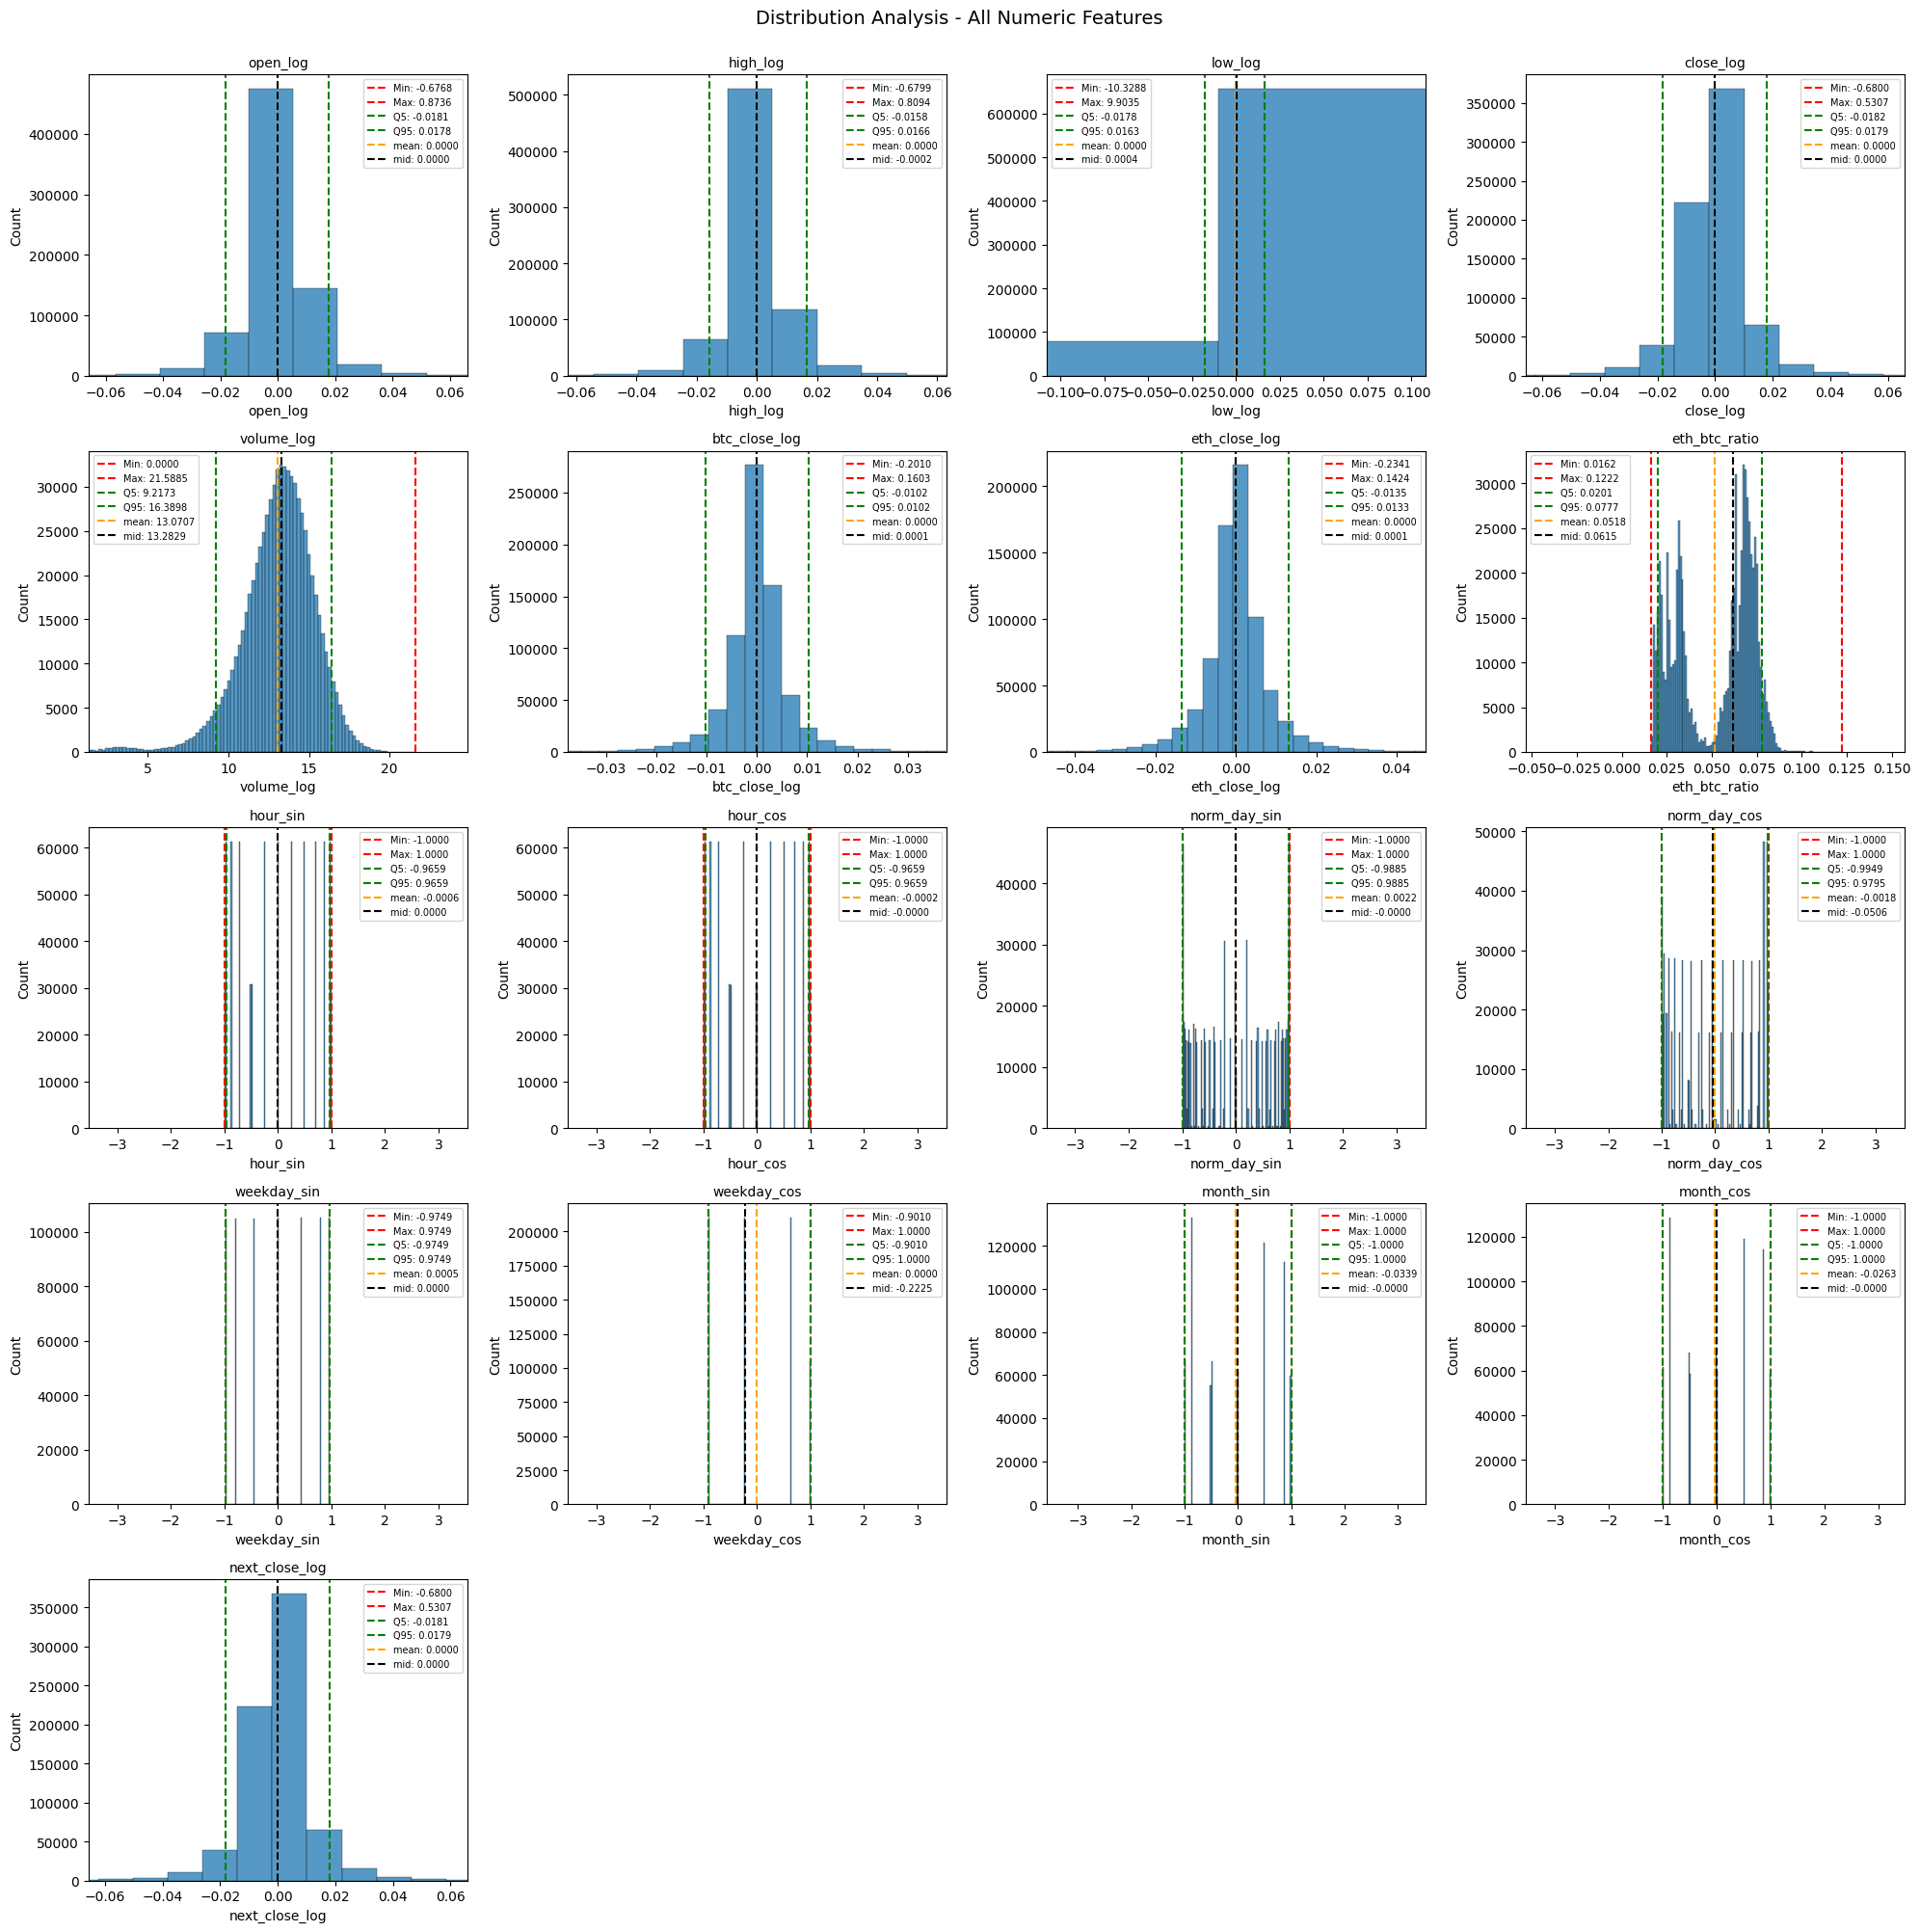

In [5]:
# Grid of histograms for all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Exclude time_idx and year
numeric_cols = [col for col in numeric_cols if col not in ['time_idx', 'year']]

n_cols_grid = 4
n_rows_grid = int(np.ceil(len(numeric_cols) / n_cols_grid))

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, n_rows_grid * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
  histo(df, col, ax=axes[idx], std_band=5, bins=100)

# Hide any unused subplots
for idx in range(len(numeric_cols), len(axes)):
  axes[idx].axis('off')

plt.suptitle('Distribution Analysis - All Numeric Features', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## Stationarity Check


In [6]:
df.symbol.unique()

array(['ADA/USD', 'ALGO/USD', 'ATOM/USD', 'BAL/USD', 'BCH/USD', 'BNB/USD',
       'COMP/USD', 'DENT/USD', 'DOGE/USD', 'ETC/USD', 'HBAR/USD',
       'LINK/USD', 'LTC/USD', 'MATIC/USD', 'MKR/USD', 'RVN/USD',
       'SOL/USD', 'TRX/USD', 'XMR/USD'], dtype=object)

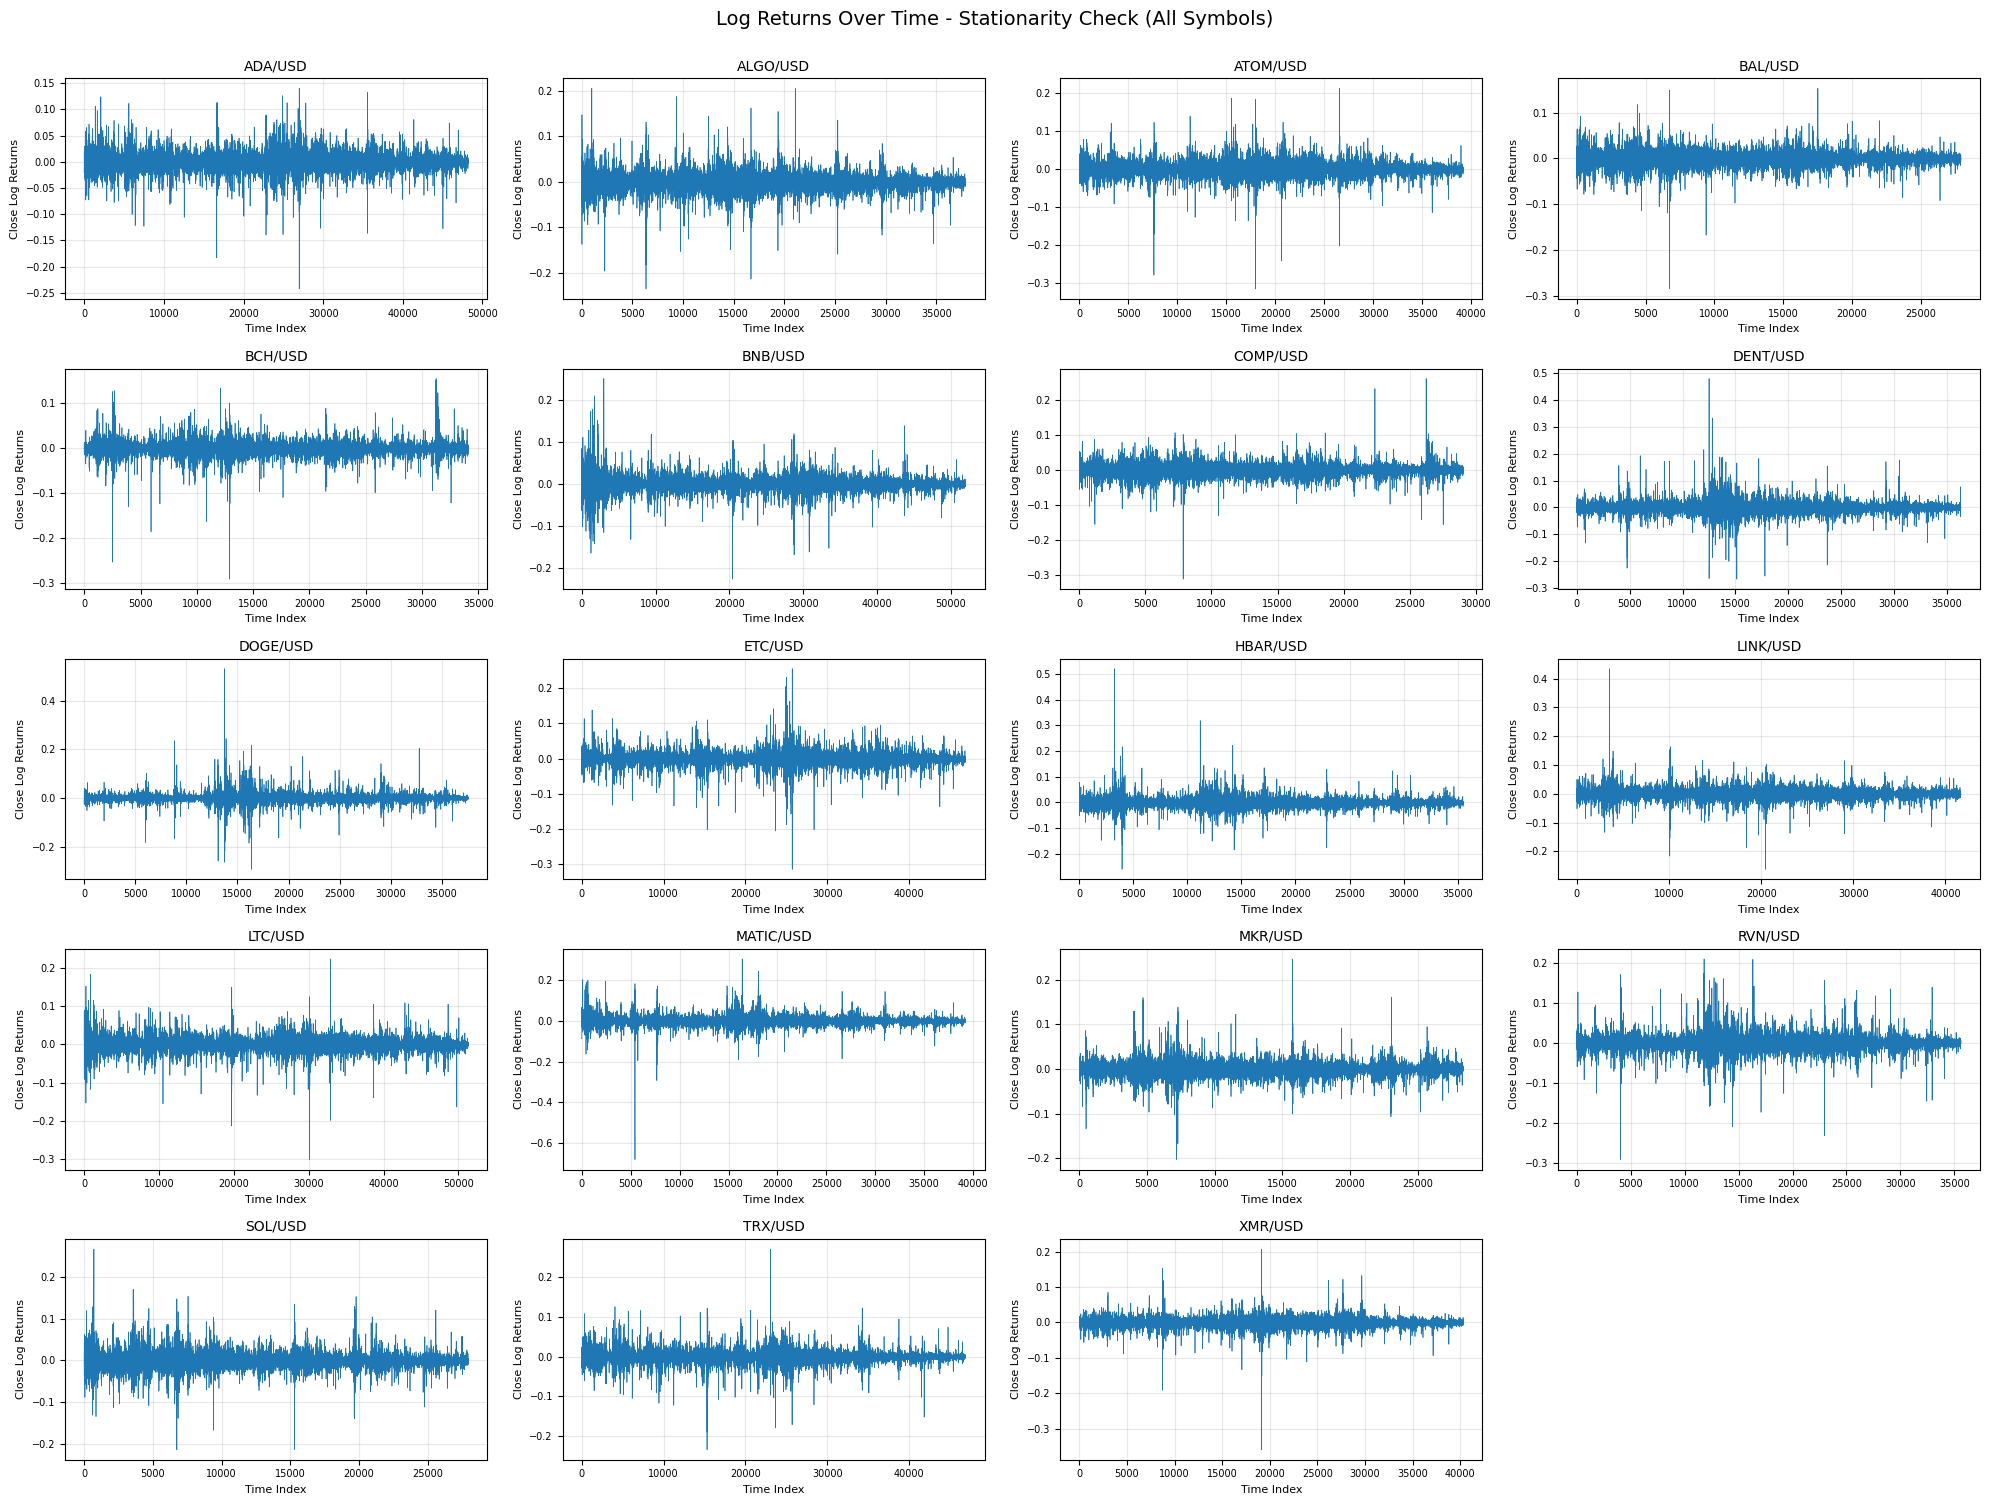

In [7]:
# Group by time windows and check if stats are stable - Grid view for all symbols
symbols = df['symbol'].unique()
n_symbols = len(symbols)
n_cols = 4
n_rows = int(np.ceil(n_symbols / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()  # Flatten to easily iterate

for idx, symbol in enumerate(symbols):
  df_sample = df[df['symbol'] == symbol]
  axes[idx].plot(df_sample['time_idx'], df_sample['close_log'], linewidth=0.5)
  axes[idx].set_title(f'{symbol}', fontsize=10)
  axes[idx].set_xlabel('Time Index', fontsize=8)
  axes[idx].set_ylabel('Close Log Returns', fontsize=8)
  axes[idx].tick_params(axis='both', labelsize=7)
  axes[idx].grid(alpha=0.3)

# Hide any unused subplots
for idx in range(n_symbols, len(axes)):
  axes[idx].axis('off')

plt.suptitle(
  'Log Returns Over Time - Stationarity Check (All Symbols)', fontsize=14, y=1.00
)
plt.tight_layout()
plt.show()

## Feature Correlation


Text(0.5, 1.0, 'Feature Correlation Matrix')

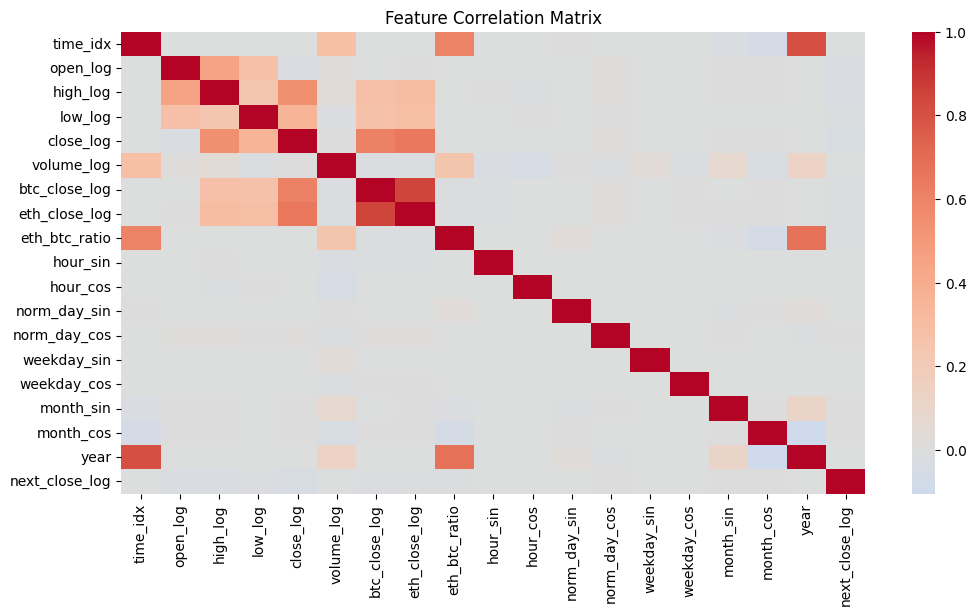

In [8]:
# See which features are correlated
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')

## Outliers


In [9]:
# How many extreme outliers?
Q1 = df['close_log'].quantile(0.25)
Q3 = df['close_log'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['close_log'] < Q1 - 3 * IQR) | (df['close_log'] > Q3 + 3 * IQR)]
print(f'Outliers: {len(outliers)} ({100 * len(outliers) / len(df):.2f}%)')

Outliers: 18501 (2.51%)


## Volatility Analysis


Text(0.5, 1.0, 'Volatility by Token (Std Dev of Log Returns)')

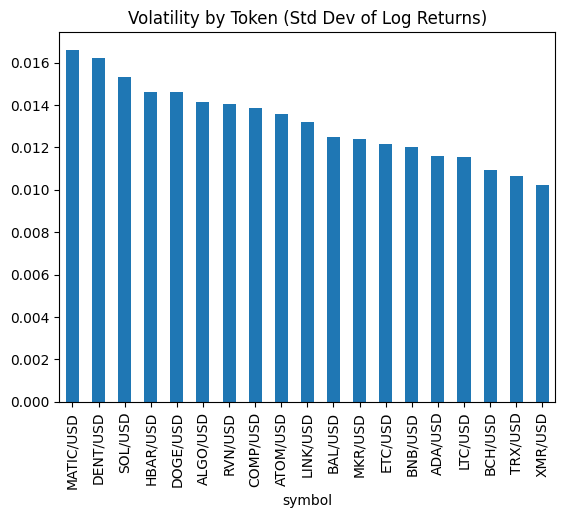

In [10]:
# Which tokens are most volatile?
volatility = df.groupby('symbol')['close_log'].std().sort_values(ascending=False)
volatility.plot(kind='bar')
plt.title('Volatility by Token (Std Dev of Log Returns)')

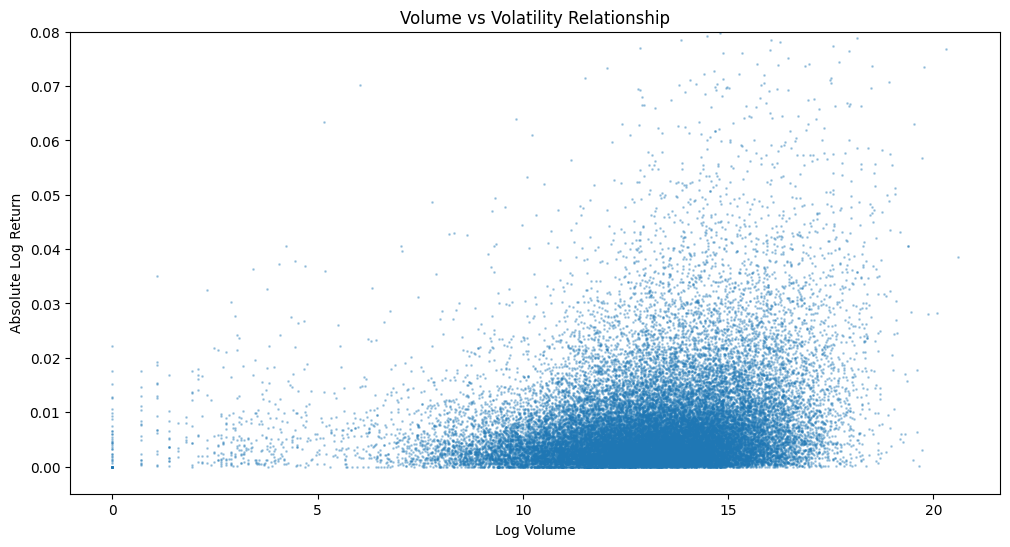

In [30]:
# Do high volume periods have different volatility?
sample_size_pct = 0.05
df['abs_return'] = df['close_log'].abs()
sdf = df.sample(int(len(df) * sample_size_pct))

plt.figure(figsize=(12, 6))
plt.scatter(sdf['volume_log'], sdf['abs_return'], alpha=0.3, s=1)
plt.ylim(bottom=-0.005, top=0.08)
plt.xlabel('Log Volume')
plt.ylabel('Absolute Log Return')
plt.title('Volume vs Volatility Relationship')
plt.show()

/var/folders/zf/pd74vy996kg6l6dpbrpqm1jr0000gn/T/ipykernel_34865/249925264.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['close_log'].corr(x['btc_close_log']))


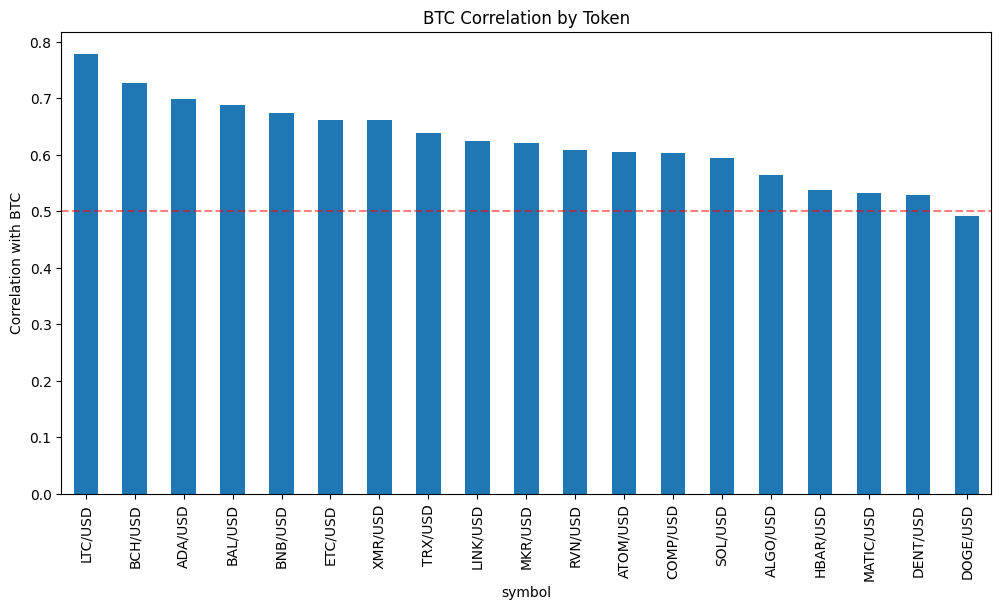

In [12]:
# Correlation by token - which tokens are most/least BTC-dependent?
btc_corr = (
  df.groupby('symbol')
  .apply(lambda x: x['close_log'].corr(x['btc_close_log']))
  .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
btc_corr.plot(kind='bar')
plt.title('BTC Correlation by Token')
plt.ylabel('Correlation with BTC')
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.show()

Based on the visuals it looks like the preprocessed data looks good!

We have normal distributions, no extreme unexpected correlations, stationarity even on the most
volatile tokens, and strong hints at a btc/eth price and alt coin price correlation.

This correlation could lend invaluable insights for our predictions.
